<a href="https://colab.research.google.com/github/avishek-astra/Deep_Learning_Experiments/blob/main/CNN_findGauss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
#import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

#summary info on labels
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Create Gaussian blurs with different width

In [48]:
nGauss=1000
imgSize=91

x=np.linspace(-4,4,imgSize)
X,Y=np.meshgrid(x,x)



#initialize tensors containing images and labels
images=torch.zeros(nGauss,1,imgSize,imgSize)
labels=torch.zeros(nGauss,3)

for i in range(nGauss):
  #location and width parameters
  loc=np.max(x)/2*np.random.randn(2) #center coordinate
  wid=np.random.rand()*10+5 #width of gaussian

  #create the guassian with random centers
  G=np.exp(-((X-loc[0])**2+(Y-loc[1])**2)/(wid))
  G=G+np.random.randn(imgSize,imgSize)/10
  images[i,:,:,:]=torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i,:]=torch.Tensor([loc[0],loc[1],wid])



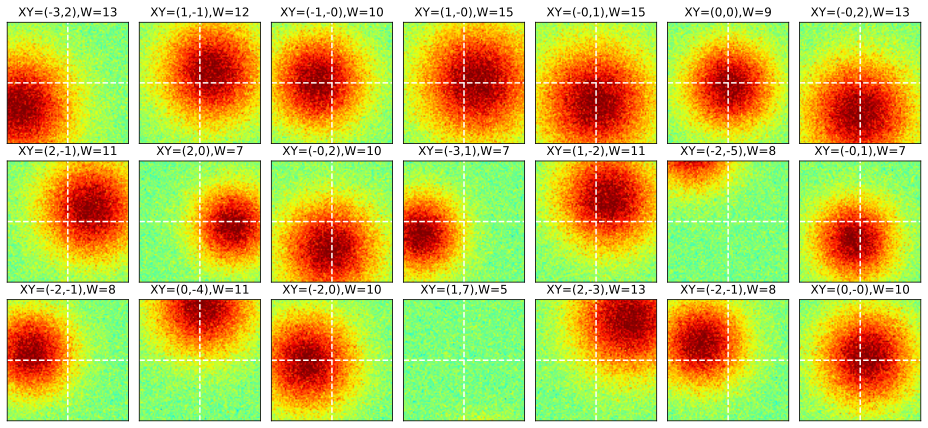

In [49]:
#visualize some images
fig,axs=plt.subplots(3,7,figsize=(13,6))
for i,ax in enumerate(axs.flatten()):
  whichpic=np.random.randint(nGauss)
  G=np.squeeze(images[whichpic,:,:])
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='upper')
  ax.set_title(f'XY=({labels[whichpic,0]:.0f},{labels[whichpic,1]:.0f}),W={labels[whichpic,2]:.0f}')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')
  ax.set_xticks([])
  ax.set_yticks([])
plt.tight_layout()
plt.show()

Create train/test group using Dataloader

In [50]:
#use scikitlearn to spilit the data
train_data,test_data,train_labels,test_labels=train_test_split(images,labels,test_size=0.1)
#convert into pytorch datasets
train_data=TensorDataset(train_data,train_labels)
test_data=TensorDataset(test_data,test_labels)
#translate into dataloader objects
batchsize=16
train_loader=DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader=DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

Create the DL model

In [51]:
from typing import NewType
#create a class for the model
def makeTheNet():
  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()
      self.enc=nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),  # output size: (91+2*1-3)/1 + 1 = 91
          nn.ReLU(),                   # note that relu is treated like a "layer"
          nn.AvgPool2d(2,2),           # output size: 91/2 = 45
          nn.Conv2d(6,4,3,padding=1),  # output size: (45+2*1-3)/1 + 1 = 45
          nn.ReLU(),
          nn.AvgPool2d(2,2),           # output size: 45/2 = 22
          #linear layer
          nn.Flatten(),
          nn.Linear(22*22*4,50),
          nn.Linear(50,3),
      )
    def forward(self,x):
      return self.enc(x) # Fixed typo here
  #create the model instance
  net=gausnet()
  #loss function
  lossfun=nn.MSELoss()
  #optimizer
  optimizer=torch.optim.Adam(net.parameters(),lr=0.001)
  return net,lossfun,optimizer

In [52]:
#test the model with one batch
net,lossfun,optimizer=makeTheNet()
X,y=next(iter(train_loader))
yHat=net(X)
#check size of input
print(yHat)
print(' ')
print(yHat.shape)


#now let's compute the loss
loss=lossfun(yHat,y)
print(' ')
print('Loss')
print(loss)


tensor([[-0.0967,  0.0754, -0.1016],
        [-0.0831,  0.0833, -0.0867],
        [-0.0861,  0.0851, -0.0874],
        [-0.0868,  0.0737, -0.0891],
        [-0.0863,  0.0789, -0.0900],
        [-0.0952,  0.0728, -0.0951],
        [-0.0864,  0.0662, -0.0978],
        [-0.0873,  0.0692, -0.0920],
        [-0.0855,  0.0721, -0.0920],
        [-0.0953,  0.0761, -0.0896],
        [-0.0906,  0.0790, -0.0874],
        [-0.0917,  0.0684, -0.0920],
        [-0.0921,  0.0670, -0.0952],
        [-0.0867,  0.0714, -0.0911],
        [-0.0893,  0.0749, -0.0949],
        [-0.0861,  0.0784, -0.0961]], grad_fn=<AddmmBackward0>)
 
torch.Size([16, 3])
 
Loss
tensor(42.8475, grad_fn=<MseLossBackward0>)


In [53]:

# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         AvgPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         AvgPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
            Linear-9                    [-1, 3]             153
Total params: 97,283
Trainable params: 97,283
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.00
Params size (MB): 0.37
Estimated Total Size (MB): 1.41
---------------------------------------------

Create a function that trains the model

In [54]:
# a function that trains the model
def function2trainTheModel():
  #number of epochs
  numepochs=30
  #create a new model
  net,lossfun,optimizer=makeTheNet()

  #initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)

  #loop over epochs
  for epochi in range(numepochs):

    #loop over training data batches
    batchLoss=[]
    for X,y in train_loader:
      #forward pass
      yHat=net(X)
      #compute loss
      loss=lossfun(yHat,y)
      #backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      #loss from this batch
      batchLoss.append(loss.item())

    #end of epoch
    trainLoss[epochi]=np.mean(batchLoss)
    #test accuracy
    X,y=next(iter(test_loader))
    with torch.no_grad():
      yHat=net(X)
      loss=lossfun(yHat,y)
    #extract the loss for this test epoch
    testLoss[epochi]=loss.item()
  #function output

  return trainLoss,testLoss,net

Run the model and show the results!

In [55]:
trainLoss,testLoss,net = function2trainTheModel()


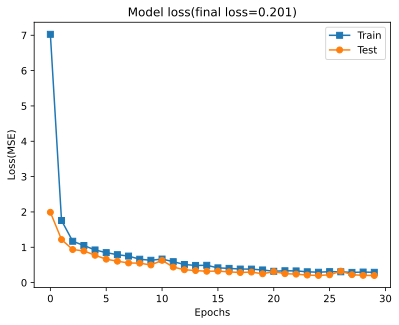

In [56]:
plt.plot(trainLoss,'s-',label='Train')
plt.plot(testLoss,'o-',label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss(MSE)')
plt.legend()
plt.title('Model loss(final loss=%.3f)'%testLoss[-1])
plt.show()

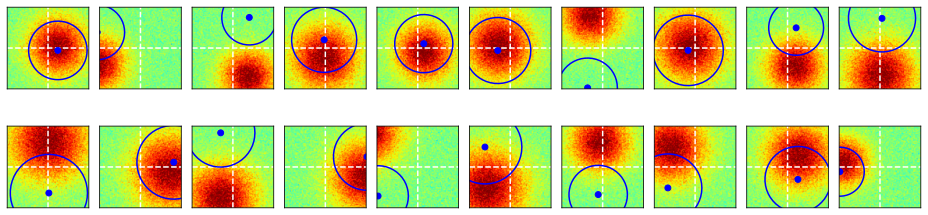

In [57]:
#visualize some images
X,Y=next(iter(test_loader))
yHat=net(X)

fig,axs=plt.subplots(2,10,figsize=(13,4))
th=np.linspace(0,2*np.pi)
for i,ax in enumerate(axs.flatten()):
  G=np.squeeze(X[i,:,:,:]).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='upper')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')
  #compute the model's prediction
  cx=yHat[i][0].item() #center X
  cy=yHat[i][1].item() #center Y
  rd=yHat[i][2].item()  #radius

  #and draw it
  x=cx+np.cos(th)*np.sqrt(rd)
  y=cy+np.sin(th)*np.sqrt(rd)
  ax.plot(x,y,'b')
  ax.plot(cx,cy,'bo')

  #some final plotting niceties
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_xlim([-4,4])
  ax.set_ylim([-4,4])
plt.tight_layout()
plt.show()